## 06. Model Evaluation

### Objective

Evaluate the trained classification models using visual and numerical metrics.

The analysis includes:

- Metric comparison.
- Confusion matrices.
- ROC curves.
- Precision-recall curves.
- Feature importance.
- Prediction error analysis.
- Final model selection.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [3]:
data_path = Path(
    "../data/processed/telco_customer_churn_modeling.csv"
)

df = pd.read_csv(data_path)

df.head()

,tenure,monthly_charges,total_charges,long_term_contract,automatic_payment,has_internet,number_of_services,gender_female,gender_male,senior_citizen_no,...,paperless_billing_yes,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,tenure_group_0_12_months,tenure_group_13_24_months,tenure_group_25_48_months,tenure_group_49_72_months,churn
0,1,29.85,29.85,0,0,1,1,1,0,1,...,1,0,0,1,0,1,0,0,0,0
1,34,56.95,1889.50,1,0,1,3,0,1,1,...,0,0,0,0,1,0,0,1,0,0
2,2,53.85,108.15,0,0,1,3,0,1,1,...,1,0,0,0,1,1,0,0,0,1
3,45,42.30,1840.75,1,1,1,3,0,1,1,...,0,1,0,0,0,0,0,1,0,0
4,2,70.70,151.65,0,0,1,1,1,0,1,...,1,0,0,1,0,1,0,0,0,1


In [4]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())

Dataset shape: (7043, 55)
Missing values: 0


In [5]:
X = df.drop(columns=["churn"]).copy()
y = df["churn"].copy()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
continuous_features = [
    "tenure",
    "monthly_charges",
    "total_charges",
    "number_of_services"
]

In [8]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_test[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

In [9]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [10]:
models_directory = Path("../models")

models = {
    "Logistic Regression": joblib.load(
        models_directory / "logistic.joblib"
    ),
    "Random Forest": joblib.load(
        models_directory / "random_forest.joblib"
    ),
    "Gradient Boosting": joblib.load(
        models_directory / "gradient_boosting.joblib"
    )
}

In [11]:
models.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'Gradient Boosting'])

In [12]:
evaluation_results = []

for model_name, model in models.items():

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

In [13]:
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7339,0.4992,0.7941,0.6130,0.8418
1,Random Forest,0.7651,0.5501,0.6310,0.5878,0.8215
2,Gradient Boosting,0.8034,0.6655,0.5214,0.5847,0.8424


In [14]:
metrics_long = evaluation_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

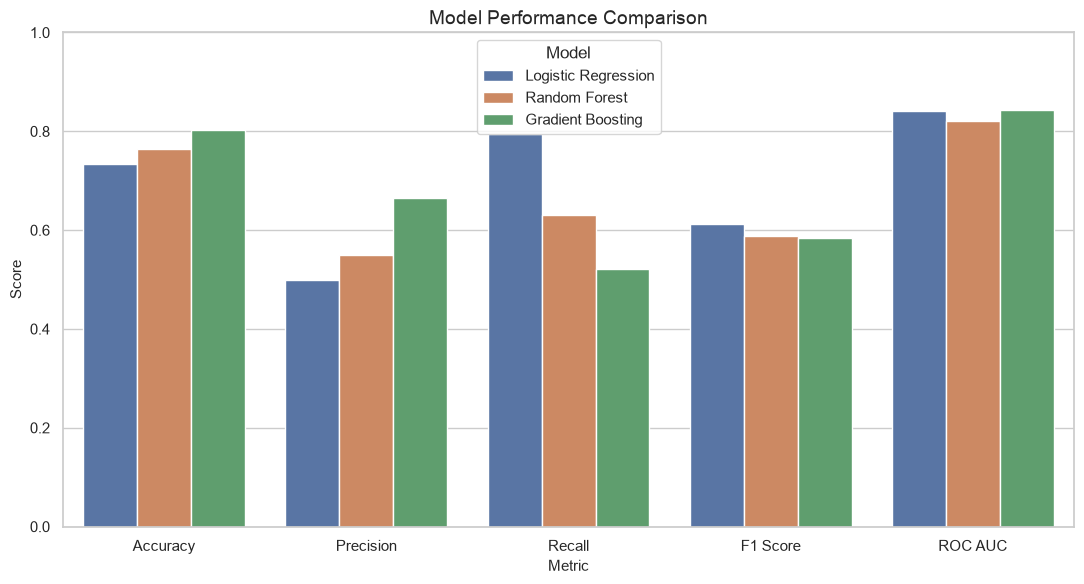

In [15]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Confusion Matrices

The confusion matrix shows:

- True negatives: customers correctly predicted as non-churn.
- False positives: customers incorrectly classified as churn.
- False negatives: churn customers not detected by the model.
- True positives: churn customers correctly detected.

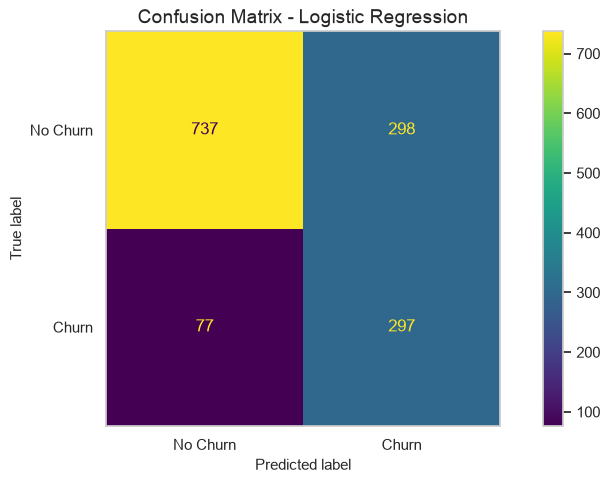

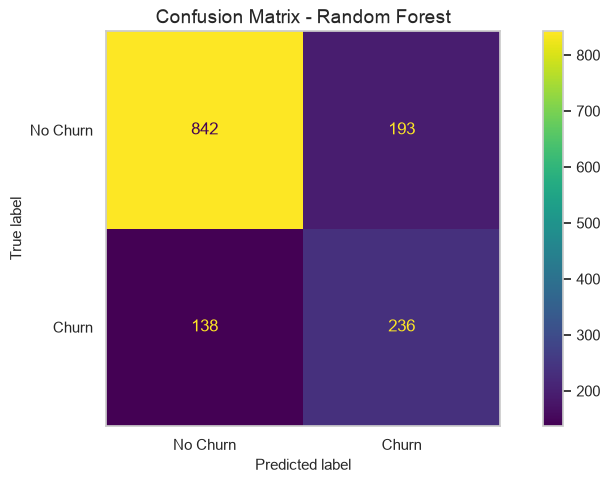

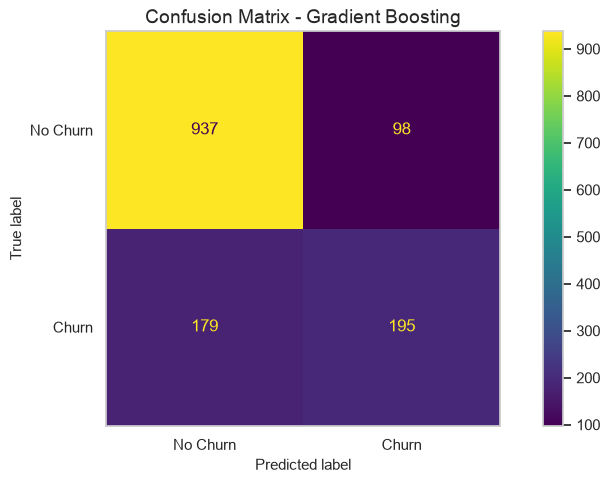

In [16]:
for model_name, model in models.items():

    predictions = model.predict(X_test)

    matrix = confusion_matrix(
        y_test,
        predictions
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Churn", "Churn"]
    )

    display.plot(
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [17]:
for model_name, model in models.items():

    predictions = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1035
       Churn       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.7

## ROC Curves

The ROC curve compares the true positive rate against the false positive rate at different classification thresholds.

A higher ROC-AUC indicates better separation between churn and non-churn customers.

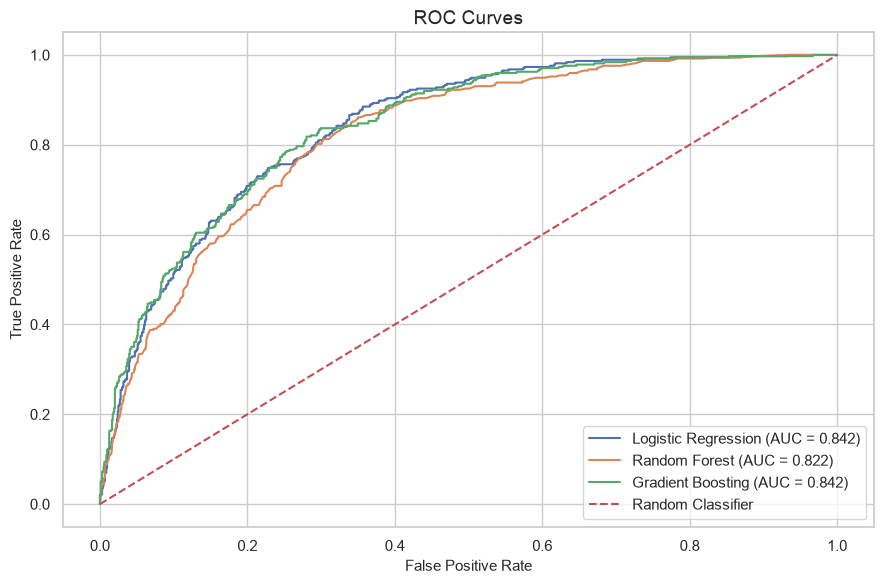

In [18]:
plt.figure(figsize=(9, 6))

for model_name, model in models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

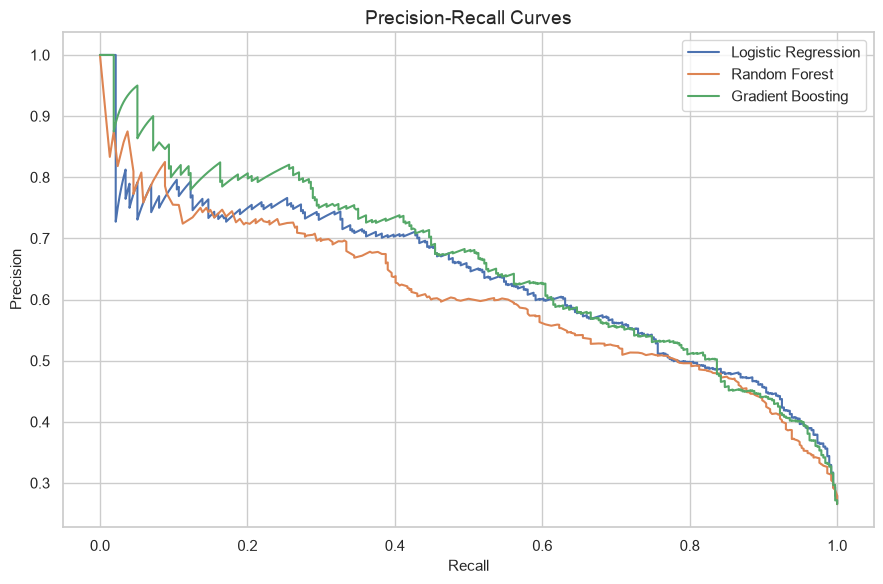

In [19]:
plt.figure(figsize=(9, 6))

for model_name, model in models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
best_result = (
    evaluation_df
    .sort_values(
        by="ROC AUC",
        ascending=False
    )
    .iloc[0]
)

best_model_name = best_result["Model"]

best_model = models[best_model_name]

print("Best model:", best_model_name)
print("ROC AUC:", round(best_result["ROC AUC"], 4))
print("Recall:", round(best_result["Recall"], 4))
print("F1 Score:", round(best_result["F1 Score"], 4))

Best model: Gradient Boosting
ROC AUC: 0.8424
Recall: 0.5214
F1 Score: 0.5847


In [21]:
forest_model = models["Random Forest"]

forest_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": forest_model.feature_importances_
})

In [22]:
forest_importance = (
    forest_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

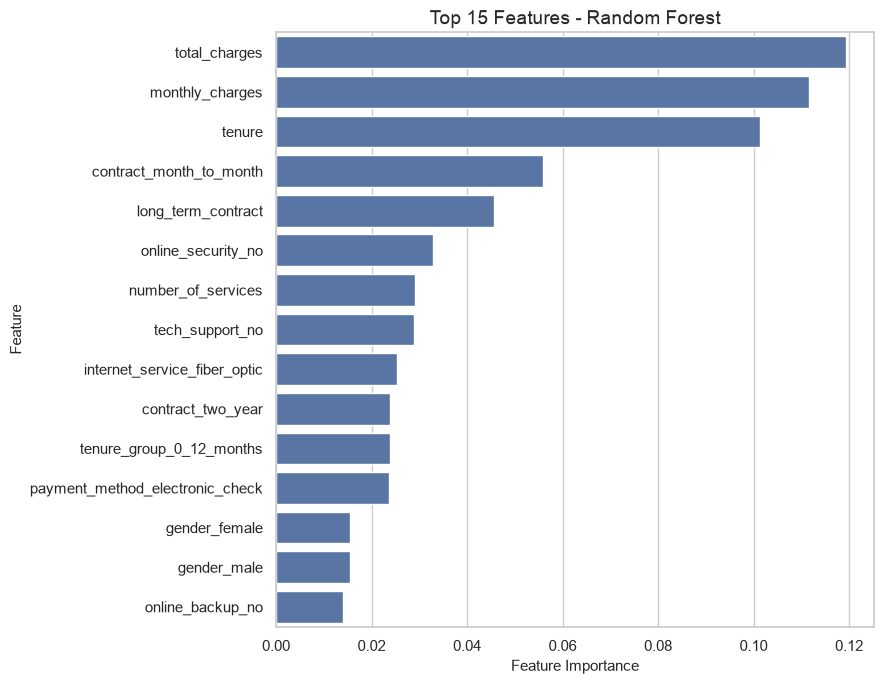

In [23]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=forest_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [24]:
boosting_model = models["Gradient Boosting"]

boosting_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": boosting_model.feature_importances_
})

In [25]:
boosting_importance = (
    boosting_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

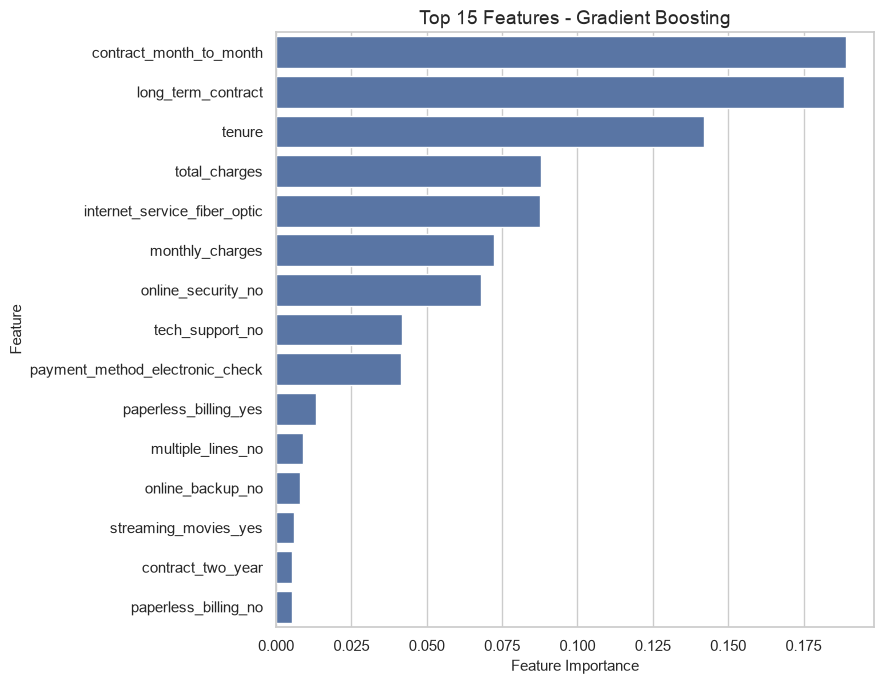

In [26]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=boosting_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Gradient Boosting")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [27]:
logistic_model = models["Logistic Regression"]

logistic_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

In [28]:
logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

In [29]:
top_logistic_features = (
    logistic_coefficients
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
    .head(15)
)

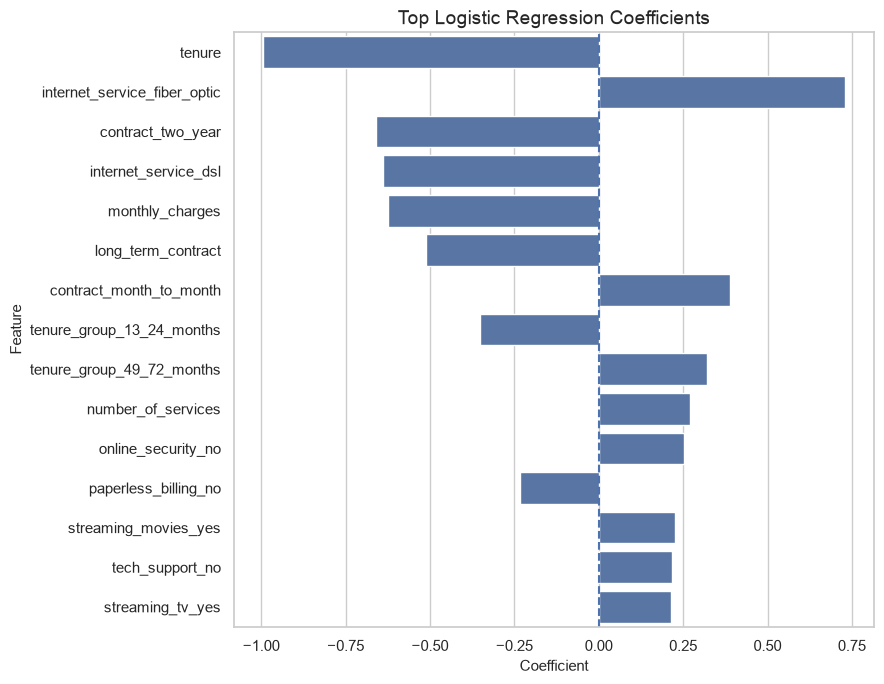

In [30]:
plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_logistic_features,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
best_predictions = best_model.predict(X_test)

best_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

In [32]:
error_analysis = X_test.copy()

error_analysis["actual_churn"] = y_test.values
error_analysis["predicted_churn"] = best_predictions
error_analysis["churn_probability"] = best_probabilities

In [33]:
error_analysis["prediction_result"] = "Correct"

error_analysis.loc[
    (
        error_analysis["actual_churn"] == 0
    )
    & (
        error_analysis["predicted_churn"] == 1
    ),
    "prediction_result"
] = "False Positive"

error_analysis.loc[
    (
        error_analysis["actual_churn"] == 1
    )
    & (
        error_analysis["predicted_churn"] == 0
    ),
    "prediction_result"
] = "False Negative"

In [34]:
error_analysis["prediction_result"].value_counts()

prediction_result
Correct           1132
False Negative     179
False Positive      98
Name: count, dtype: int64

In [35]:
error_counts = (
    error_analysis["prediction_result"]
    .value_counts()
    .reset_index()
)

error_counts.columns = [
    "Prediction Result",
    "Count"
]

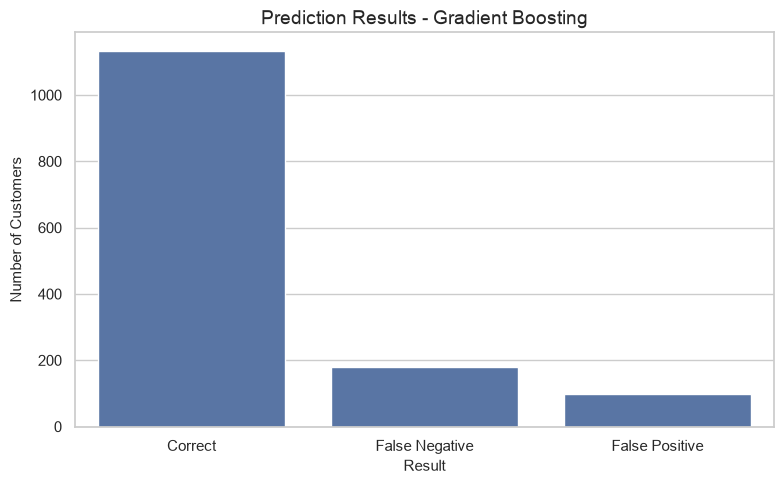

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=error_counts,
    x="Prediction Result",
    y="Count"
)

plt.title(f"Prediction Results - {best_model_name}")
plt.xlabel("Result")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [37]:
false_negatives = error_analysis[
    error_analysis["prediction_result"]
    == "False Negative"
].copy()

In [38]:
false_negatives[
    [
        "tenure",
        "monthly_charges",
        "total_charges",
        "number_of_services",
        "churn_probability"
    ]
].head(10)

,tenure,monthly_charges,total_charges,number_of_services,churn_probability
1639,-0.630332,-0.659687,-0.670791,-1.150692,0.339169
761,-0.426803,0.807025,-0.171779,-0.184954,0.374866
950,-1.240918,-0.663006,-0.971559,-1.150692,0.474498
2488,-0.060452,-0.321215,-0.256114,-0.184954,0.157902
523,-0.386098,0.354070,-0.237268,-0.667823,0.219314
5086,0.509429,-1.477661,-0.600651,-1.150692,0.038712
3408,-1.159507,-0.472200,-0.942533,-0.667823,0.298958
3362,-1.281624,-0.332830,-0.984832,-0.184954,0.480395
7011,-1.159507,-0.150320,-0.889505,0.297915,0.153253
3158,-0.589626,-0.510361,-0.623512,-0.667823,0.193180


In [39]:
probability_df = pd.DataFrame({
    "Actual Churn": y_test.map({
        0: "No Churn",
        1: "Churn"
    }),
    "Churn Probability": best_probabilities
})

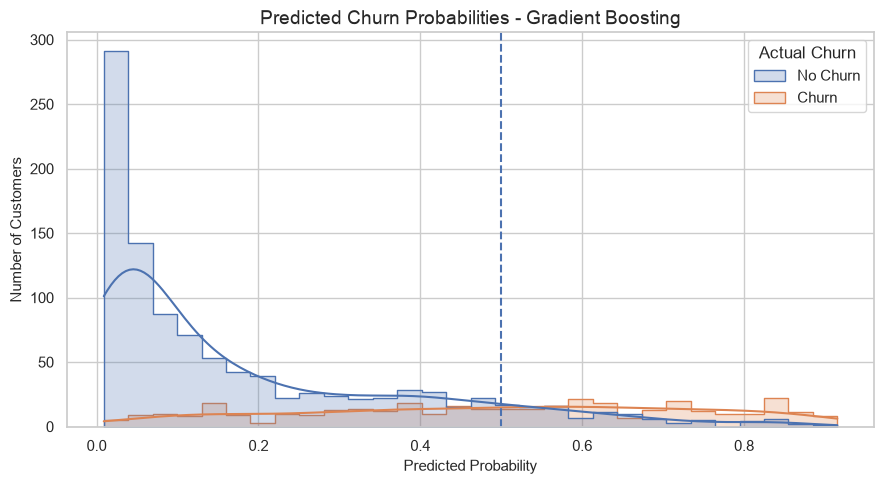

In [40]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=probability_df,
    x="Churn Probability",
    hue="Actual Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.axvline(
    x=0.50,
    linestyle="--"
)

plt.title(
    f"Predicted Churn Probabilities - {best_model_name}"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [41]:
threshold_results = []

for threshold in [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]:

    threshold_predictions = (
        best_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        )
    })

In [42]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.5312,0.7513,0.6224
1,0.35,0.5567,0.7086,0.6235
2,0.40,0.5856,0.6310,0.6075
3,0.45,0.6282,0.5829,0.6047
4,0.50,0.6655,0.5214,0.5847
5,0.55,0.6971,0.4492,0.5463
6,0.60,0.7263,0.3690,0.4894


In [43]:
threshold_long = threshold_df.melt(
    id_vars="Threshold",
    var_name="Metric",
    value_name="Score"
)

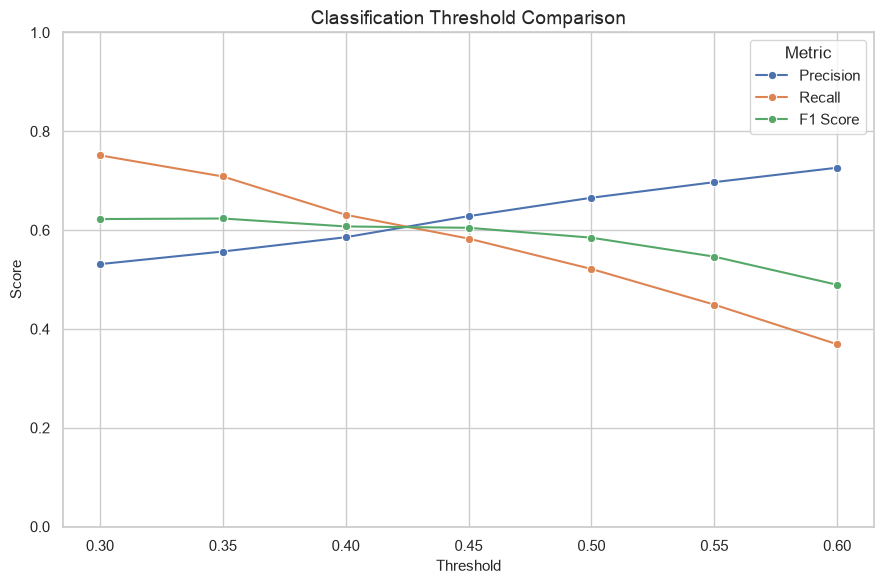

In [44]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=threshold_long,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o"
)

plt.ylim(0, 1)
plt.title("Classification Threshold Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [45]:
best_threshold_row = (
    threshold_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]
)

selected_threshold = best_threshold_row["Threshold"]

print(
    "Selected threshold:",
    selected_threshold
)

print(
    "F1 Score:",
    round(
        best_threshold_row["F1 Score"],
        4
    )
)

Selected threshold: 0.35
F1 Score: 0.6235


In [46]:
reports_directory = Path("../reports")

reports_directory.mkdir(
    parents=True,
    exist_ok=True
)

In [47]:
evaluation_df.to_csv(
    reports_directory / "model_evaluation.csv",
    index=False
)

threshold_df.to_csv(
    reports_directory / "threshold_evaluation.csv",
    index=False
)

forest_importance.to_csv(
    reports_directory / "random_forest_feature_importance.csv",
    index=False
)

boosting_importance.to_csv(
    reports_directory / "gradient_boosting_feature_importance.csv",
    index=False
)

In [48]:
joblib.dump(
    best_model,
    models_directory / "best_churn_model.joblib"
)

['../models/best_churn_model.joblib']

In [49]:
joblib.dump(
    scaler,
    models_directory / "standard_scaler.joblib"
)

['../models/standard_scaler.joblib']

## Conclusion

The trained models were evaluated using classification metrics, confusion matrices, ROC curves, precision-recall curves, and feature importance.

The final model was selected primarily using ROC-AUC, F1-score, and churn recall.

The analysis also showed that the default classification threshold of 0.50 is not always the best business decision. Lower thresholds can identify more customers at risk, although they may generate additional false-positive alerts.

The most influential variables were mainly related to customer tenure, contract type, monthly charges, internet service, payment method, and support services.

The selected model and preprocessing scaler were saved for future use in customer churn predictions and dashboard development.